# 232 millones de personas dicen lo mismo: la obesidad se desacelera donde más subió

> Un equipo internacional juntó **4.050 estudios** poblacionales y midió (no preguntó) altura y peso de **232 millones** de personas en **200 países** entre 1980 y 2024.

**Paper:** [Obesity rise plateaus in developed nations and accelerates in developing nations](https://doi.org/10.1038/s41586-026-10383-0) · *Nature, 2026-05-13* · NCD Risk Factor Collaboration

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-13-obesidad-platea-vs-acelera/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/_sDKEX926eU)

## Qué hicieron

Hasta ahora la mayoría de comparaciones de obesidad mundial agrupan décadas enteras y se pierden el ritmo: ¿está subiendo más rápido, frenándose, revirtiendo? El consorcio NCD-RisC armó la base más grande hasta la fecha con altura y peso **medidos en clínica** (no autoreportados — la gente suele bajarse 1-2 kg al declarar) y reconstruyó la prevalencia año por año.

Lo que les salió no es lo que esperaban: en varios países ricos la curva ya no sube — y en algunos casos baja. En cambio, las regiones de ingreso medio y bajo aceleraron justo cuando las ricas se frenaron.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ANO_FOCO = 2024              # Año de referencia para comparaciones
ANO_INICIO = 1980            # Año base del estudio
FUENTE = 'Fuente: NCD-RisC (2026), Nature | Datos: ncdrisc.org · Zenodo 10.5281/zenodo.18368826'

# Paleta CaM
COLOR_PRINCIPAL = '#2563EB'  # Azul (datos principales)
COLOR_ALERTA = '#DC2626'     # Rojo (extremos, alertas)
COLOR_SECUNDARIO = '#059669' # Emerald
COLOR_REFERENCIA = '#D97706' # Amber
COLOR_CONTEXTO = '#BBBBBB'   # Gris (líneas de fondo)

# Helper de formato español (coma decimal)
def es(x, dec=1):
    return f"{x:.{dec}f}".replace(".", ",")

# ──────────────────────────────────────────────────────────────
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar estilo CaM (local primero, fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Crear directorio de figuras
os.makedirs('figuras', exist_ok=True)

# Cargar datasets
adultos_mundo = pd.read_csv('datos/obesidad_adultos_mundo.csv')
ninos_mundo   = pd.read_csv('datos/obesidad_ninos_mundo_edad10.csv')
adultos_pais  = pd.read_csv('datos/obesidad_adultos_pais.csv')
ninos_pais    = pd.read_csv('datos/obesidad_ninos_pais.csv')
regiones      = pd.read_csv('datos/obesidad_regiones.csv')
estudios      = pd.read_csv('datos/estudios_por_anio.csv')

print(f"Datasets cargados ({ANO_INICIO}-{ANO_FOCO}):")
print(f"  · Mundo adultos:     {len(adultos_mundo):>5} filas (años x sexo)")
print(f"  · Mundo niños 10a:   {len(ninos_mundo):>5} filas")
print(f"  · País adultos:      {len(adultos_pais):>5} filas — {adultos_pais['country'].nunique()} países")
print(f"  · País niños:        {len(ninos_pais):>5} filas — {ninos_pais['country'].nunique()} países")
print(f"  · Regiones:          {len(regiones):>5} filas — 8 regiones, adultos+niños")
print(f"  · Estudios/año:      {len(estudios):>5} años de cobertura (1975-2025)")
print(f"\nTotal estudios: {int(estudios['n_studies'].sum()):,} · Total participantes: {int(estudios['n_participants'].sum()):,}")

Datasets cargados (1980-2024):
  · Mundo adultos:        90 filas (años x sexo)
  · Mundo niños 10a:      90 filas
  · País adultos:      18000 filas — 200 países
  · País niños:        18000 filas — 200 países
  · Regiones:           1440 filas — 8 regiones, adultos+niños
  · Estudios/año:         51 años de cobertura (1975-2025)

Total estudios: 4,050 · Total participantes: 231,754,544


## Aquí está.

Cinco países, chicos y chicas de 5-19 años. Misma definición, misma metodología, mismas fechas. El gráfico cuenta toda la historia.

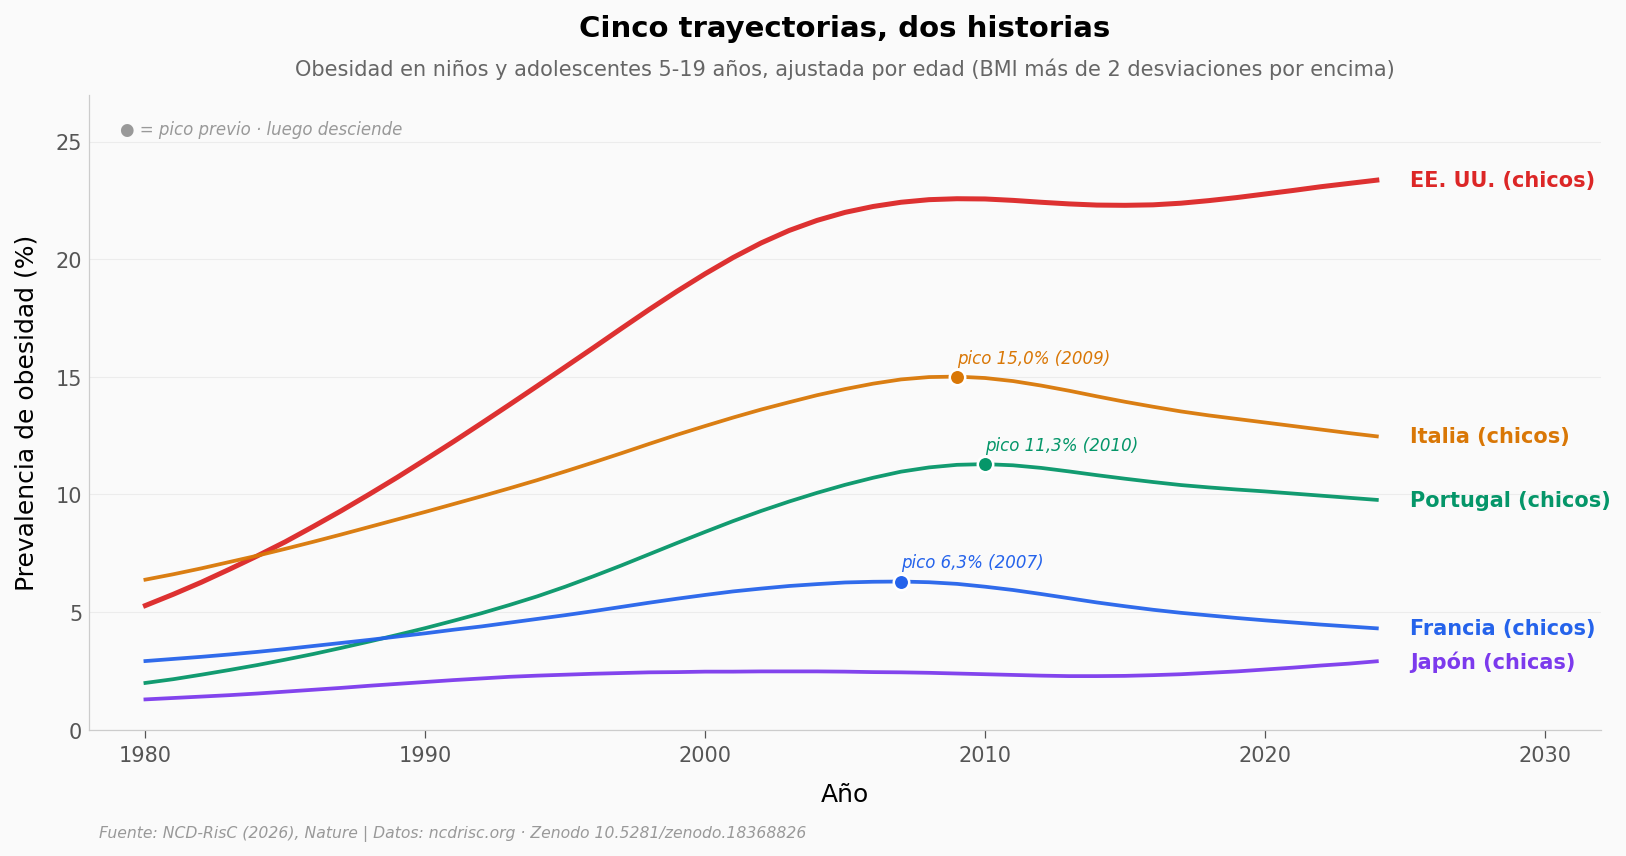

In [2]:
# Gráfica hero: 5 trayectorias que cuentan la dualidad
fig, ax = plt.subplots(figsize=(13, 5.5))

# Selección: USA boys (extremo alto + plateau), Italia/Francia/Portugal boys (peak + declive),
# Japan girls (extremo bajo, plano)
casos = [
    ('United States of America', 'Boys',  'EE. UU. (chicos)',  COLOR_ALERTA,     2.4),
    ('Italy',                    'Boys',  'Italia (chicos)',    COLOR_REFERENCIA, 1.8),
    ('Portugal',                 'Boys',  'Portugal (chicos)',  COLOR_SECUNDARIO, 1.8),
    ('France',                   'Boys',  'Francia (chicos)',   COLOR_PRINCIPAL,  1.8),
    ('Japan',                    'Girls', 'Japón (chicas)',     '#7C3AED',        1.8),
]

for country, sex, label, color, lw in casos:
    serie = ninos_pais[(ninos_pais['country'] == country) & (ninos_pais['sex'] == sex)].sort_values('year')
    ax.plot(serie['year'], serie['obesity_pct'], color=color, linewidth=lw, alpha=0.95, zorder=5)
    # Etiqueta inline al final de cada línea
    y_end = serie[serie['year'] == 2024]['obesity_pct'].values[0]
    ax.text(2025.2, y_end, label, fontsize=10, color=color, fontweight='bold', va='center')

# Anotar peaks de Italia/Francia/Portugal (donde ya cayeron)
for country, sex, color in [('Italy', 'Boys', COLOR_REFERENCIA),
                            ('France', 'Boys', COLOR_PRINCIPAL),
                            ('Portugal', 'Boys', COLOR_SECUNDARIO)]:
    s = ninos_pais[(ninos_pais['country'] == country) & (ninos_pais['sex'] == sex)]
    idx_peak = s['obesity_pct'].idxmax()
    y_peak, x_peak = s.loc[idx_peak, 'obesity_pct'], s.loc[idx_peak, 'year']
    ax.scatter(x_peak, y_peak, color=color, s=55, edgecolors='white', linewidths=1.2, zorder=8)

ax.set_xlim(1978, 2032)
ax.set_ylim(0, 27)
ax.set_xlabel('Año')
ax.set_ylabel('Prevalencia de obesidad (%)')
ax.set_title('Cinco trayectorias, dos historias',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Obesidad en niños y adolescentes 5-19 años, ajustada por edad (BMI más de 2 desviaciones por encima)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Notas explicativas en el plot
ax.text(2009, 15.6, 'pico 15,0% (2009)', fontsize=8, color=COLOR_REFERENCIA, style='italic')
ax.text(2007, 6.9,  'pico 6,3% (2007)',  fontsize=8, color=COLOR_PRINCIPAL,  style='italic')
ax.text(2010, 11.9, 'pico 11,3% (2010)', fontsize=8, color=COLOR_SECUNDARIO, style='italic')
ax.text(0.02, 0.96, '● = pico previo · luego desciende',
        transform=ax.transAxes, fontsize=8, color='#999999', style='italic', va='top')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_brecha_paises.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que está pasando

Tres cosas que la curva nos dice y el abstract solo resume:

1. **La brecha entre extremos es de casi un orden de magnitud.** EE. UU. chicos en 2024: **23,4%** (intervalo 19,0-27,8). Japón chicas: **2,9%** (2,3-3,6). Un país occidental rico contra un país asiático rico — ambos con datos buenos, definiciones idénticas. La diferencia es ~8 veces.
2. **Italia, Francia y Portugal ya bajaron.** Los tres alcanzaron un pico entre 2007 y 2010 y desde entonces descienden. Francia es el caso más claro: del 6,3% en 2007 al 4,3% en 2024 — una caída relativa cercana al 32%.
3. **EE. UU. se estancó, no bajó.** La curva americana se plana después de 2010 (22,6% → 23,4% en 14 años). El paper lo llama *"plateaued"*: no es reversión, es freno.

## Y el mundo entero, ¿qué hizo?

Los países se mueven uno por uno, pero el promedio global cuenta el largo plazo. Veamos las dos curvas mundiales — adultos hombres y mujeres — desde 1980.

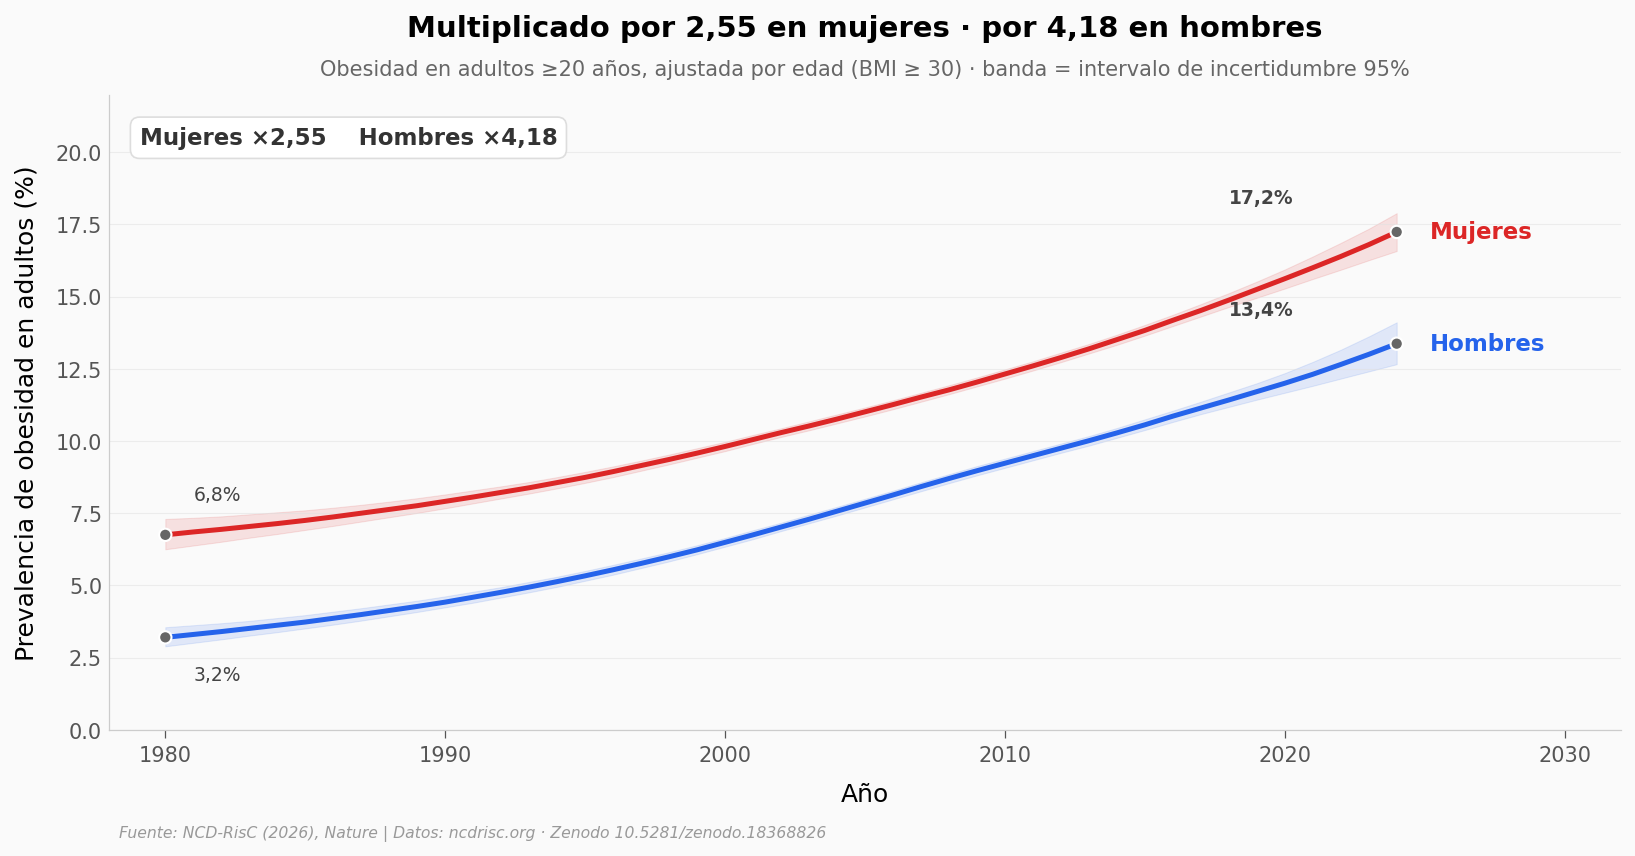

Mundo 1980: mujeres 6.75% · hombres 3.20%
Mundo 2024: mujeres 17.24% · hombres 13.37%
Multiplicador mujeres: ×2.554
Multiplicador hombres: ×4.178


In [3]:
# Mundo adultos: mujeres vs hombres con UI 95%
fig, ax = plt.subplots(figsize=(13, 5.5))

w = adultos_mundo[adultos_mundo['sex'] == 'Women'].sort_values('year')
m = adultos_mundo[adultos_mundo['sex'] == 'Men'].sort_values('year')

# Bandas de incertidumbre 95%
ax.fill_between(w['year'], w['obesity_lo95'], w['obesity_hi95'], color=COLOR_ALERTA, alpha=0.12)
ax.fill_between(m['year'], m['obesity_lo95'], m['obesity_hi95'], color=COLOR_PRINCIPAL, alpha=0.12)

ax.plot(w['year'], w['obesity_pct'], color=COLOR_ALERTA,     linewidth=2.4, zorder=5)
ax.plot(m['year'], m['obesity_pct'], color=COLOR_PRINCIPAL,  linewidth=2.4, zorder=5)

# Inline labels
ax.text(2025.2, w[w['year']==2024]['obesity_pct'].values[0], 'Mujeres', fontsize=11,
        color=COLOR_ALERTA, fontweight='bold', va='center')
ax.text(2025.2, m[m['year']==2024]['obesity_pct'].values[0], 'Hombres', fontsize=11,
        color=COLOR_PRINCIPAL, fontweight='bold', va='center')

# Anotar multiplicadores
w_1980, w_2024 = w[w['year']==1980]['obesity_pct'].values[0], w[w['year']==2024]['obesity_pct'].values[0]
m_1980, m_2024 = m[m['year']==1980]['obesity_pct'].values[0], m[m['year']==2024]['obesity_pct'].values[0]
mult_w = w_2024 / w_1980
mult_m = m_2024 / m_1980

ax.scatter([1980, 1980, 2024, 2024],
           [w_1980, m_1980, w_2024, m_2024],
           color=['#666666']*4, s=35, zorder=6, edgecolors='white', linewidths=1)

ax.annotate(f'{es(w_1980)}%', xy=(1980, w_1980), xytext=(1981, w_1980+1.2),
            fontsize=9, color='#444444')
ax.annotate(f'{es(m_1980)}%', xy=(1980, m_1980), xytext=(1981, m_1980-1.5),
            fontsize=9, color='#444444')
ax.annotate(f'{es(w_2024)}%', xy=(2024, w_2024), xytext=(2018, w_2024+1.0),
            fontsize=9, color='#444444', fontweight='bold')
ax.annotate(f'{es(m_2024)}%', xy=(2024, m_2024), xytext=(2018, m_2024+1.0),
            fontsize=9, color='#444444', fontweight='bold')

ax.set_xlim(1978, 2032)
ax.set_ylim(0, 22)
ax.set_xlabel('Año')
ax.set_ylabel('Prevalencia de obesidad en adultos (%)')
ax.set_title('Multiplicado por 2,55 en mujeres · por 4,18 en hombres',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Obesidad en adultos ≥20 años, ajustada por edad (BMI ≥ 30) · banda = intervalo de incertidumbre 95%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.02, 0.95, f'Mujeres ×{es(mult_w, 2)}    Hombres ×{es(mult_m, 2)}',
        transform=ax.transAxes, fontsize=11, color='#333333', fontweight='bold', va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#DDDDDD', linewidth=0.8))

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_mundo_w_m.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Mundo {ANO_INICIO}: mujeres {w_1980:.2f}% · hombres {m_1980:.2f}%")
print(f"Mundo {ANO_FOCO}: mujeres {w_2024:.2f}% · hombres {m_2024:.2f}%")
print(f"Multiplicador mujeres: ×{mult_w:.3f}")
print(f"Multiplicador hombres: ×{mult_m:.3f}")

## Por qué la curva mundial sigue subiendo

Si Italia, Francia y Portugal ya bajaron, ¿por qué el promedio global aún sube? Porque el peso de las regiones cambió. Cuando un país pequeño revierte, mueve poco la aguja; cuando una región de mil millones de habitantes acelera, mueve mucho.

Aquí están las tasas anuales de cambio en mujeres adultas, agrupadas en dos eras: 1980-2000 (cuando el mundo se occidentalizó dietéticamente) y 2000-2024 (cuando algo cambió).

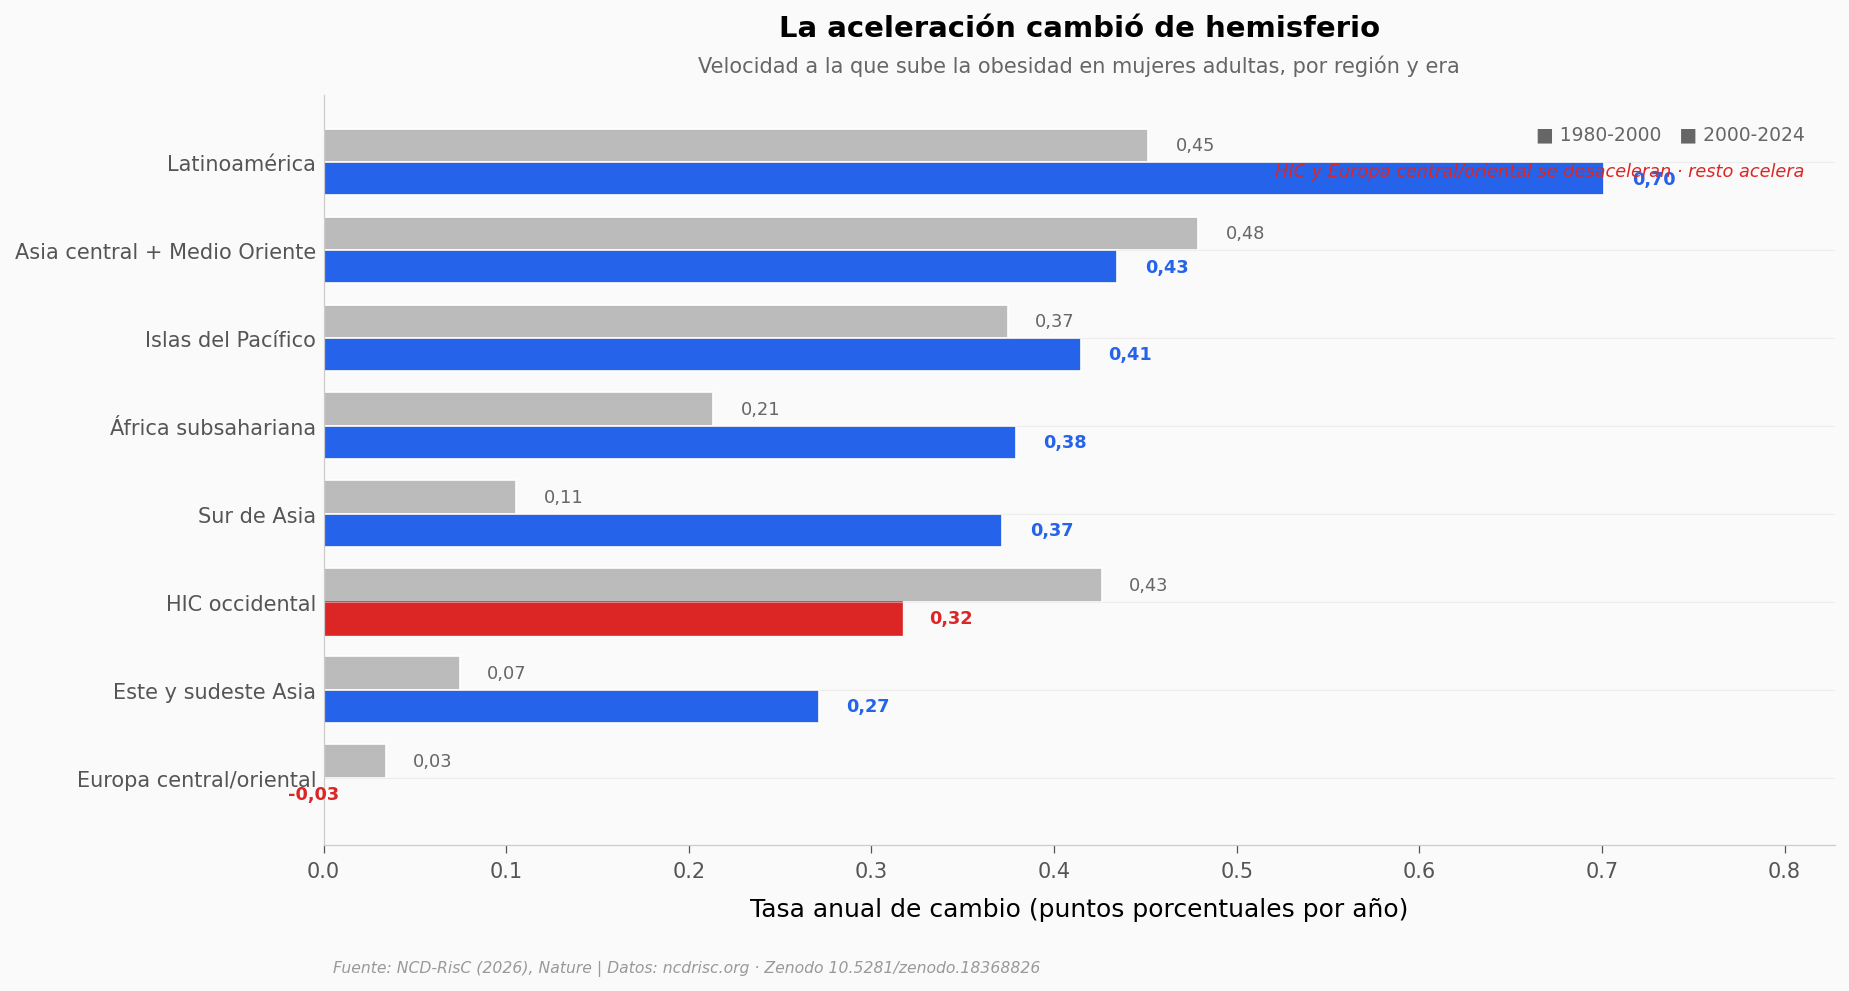


Tasas anuales (puntos porcentuales por año) — mujeres adultas
                      region  tasa_80_00  tasa_00_24  aceleracion
     Europa central/oriental        0.03       -0.03        -1.02
         Este y sudeste Asia        0.07        0.27         3.64
              HIC occidental        0.43        0.32         0.74
                 Sur de Asia        0.11        0.37         3.52
         África subsahariana        0.21        0.38         1.78
          Islas del Pacífico        0.37        0.41         1.11
Asia central + Medio Oriente        0.48        0.43         0.91
               Latinoamérica        0.45        0.70         1.55


In [4]:
# Tasas anuales de cambio por región — mujeres adultas
adultos_reg = regiones[(regiones['grupo_edad'] == 'adultos') & (regiones['sex'] == 'Women')]

# Renombrado corto para etiquetas
region_labels = {
    'High-income western':                         'HIC occidental',
    'Central and eastern Europe':                  'Europa central/oriental',
    'Latin America and the Caribbean':             'Latinoamérica',
    'Central Asia, Middle East and north Africa':  'Asia central + Medio Oriente',
    'Sub-Saharan Africa':                          'África subsahariana',
    'South Asia':                                  'Sur de Asia',
    'East and southeast Asia and the Pacific':     'Este y sudeste Asia',
    'Pacific island nations':                      'Islas del Pacífico',
}

regs = adultos_reg['region'].unique()
data = []
for reg in regs:
    s = adultos_reg[adultos_reg['region'] == reg].set_index('year')['obesity_pct']
    tasa_80_00 = (s[2000] - s[1980]) / 20     # pp por año
    tasa_00_24 = (s[2024] - s[2000]) / 24     # pp por año
    data.append({
        'region': region_labels[reg],
        'tasa_80_00': tasa_80_00,
        'tasa_00_24': tasa_00_24,
        'aceleracion': tasa_00_24 / tasa_80_00 if tasa_80_00 > 0 else float('nan'),
    })
df_tasas = pd.DataFrame(data).sort_values('tasa_00_24', ascending=True).reset_index(drop=True)

# Barras horizontales pareadas
fig, ax = plt.subplots(figsize=(13, 6.5))
y = np.arange(len(df_tasas))
h = 0.38

bars1 = ax.barh(y + h/2, df_tasas['tasa_80_00'], height=h, color=COLOR_CONTEXTO,
                edgecolor='white', linewidth=0.8, label='1980-2000')
bars2 = ax.barh(y - h/2, df_tasas['tasa_00_24'], height=h, color=COLOR_PRINCIPAL,
                edgecolor='white', linewidth=0.8, label='2000-2024')

# Colorear HIC occidental en rojo (única que desacelera) en la barra 2000-2024
REGIONES_DESACELERAN = ('HIC occidental', 'Europa central/oriental')
for i, row in df_tasas.iterrows():
    if row['region'] in REGIONES_DESACELERAN:
        bars2[i].set_color(COLOR_ALERTA)

# Etiquetas de valor al final de cada barra
for i, row in df_tasas.iterrows():
    ax.text(row['tasa_80_00'] + 0.015, i + h/2, es(row['tasa_80_00'], 2),
            fontsize=8.5, color='#666666', va='center')
    color_lab = COLOR_ALERTA if row['region'] in REGIONES_DESACELERAN else COLOR_PRINCIPAL
    ax.text(row['tasa_00_24'] + 0.015, i - h/2, es(row['tasa_00_24'], 2),
            fontsize=8.5, color=color_lab, va='center', fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(df_tasas['region'], fontsize=10)
ax.set_xlabel('Tasa anual de cambio (puntos porcentuales por año)')
ax.set_xlim(0, max(df_tasas['tasa_00_24'].max(), df_tasas['tasa_80_00'].max()) * 1.18)
ax.set_title('La aceleración cambió de hemisferio',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Velocidad a la que sube la obesidad en mujeres adultas, por región y era',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Leyenda mínima
ax.text(0.98, 0.96, '■ 1980-2000   ■ 2000-2024',
        transform=ax.transAxes, fontsize=9, color='#666666', ha='right', va='top')
ax.text(0.98, 0.91, 'HIC y Europa central/oriental se desaceleran · resto acelera',
        transform=ax.transAxes, fontsize=8.5, color=COLOR_ALERTA, ha='right', va='top', style='italic')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_regiones_tasas.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nTasas anuales (puntos porcentuales por año) — mujeres adultas")
print(df_tasas[['region', 'tasa_80_00', 'tasa_00_24', 'aceleracion']].round(2).to_string(index=False))

## ¿Cuán heterogéneo es el mundo en 2024?

El promedio mundial fue **17,2%** en mujeres adultas — ponderado por población (China e India pesan mucho). La media simple por país, sin ponderar, es muy distinta: alrededor del **30%**. La diferencia es la pista — los países pequeños tienden a tener prevalencias mayores que los gigantes asiáticos. Veamos la distribución completa.

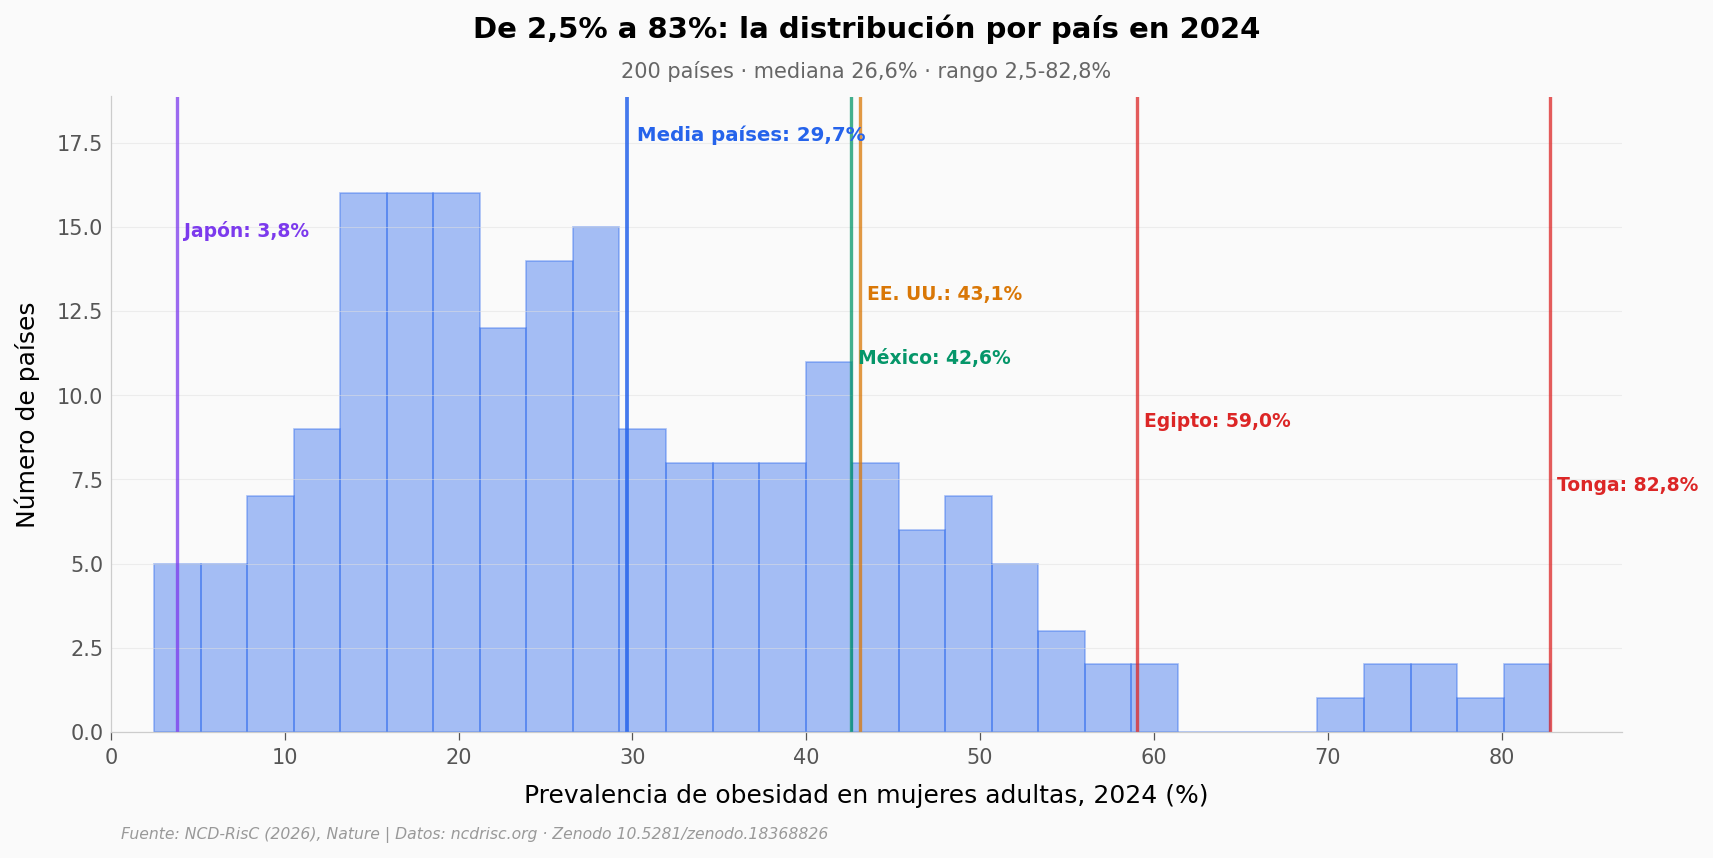


Top 5 países (mujeres adultas, 2024):
       country  obesity_pct
         Tonga        82.79
American Samoa        82.21
         Samoa        78.05
       Tokelau        75.77
  Cook Islands        75.21

Bottom 5:
   country  obesity_pct
  Viet Nam         2.49
     Japan         3.79
   Burundi         4.50
Madagascar         4.54
  Ethiopia         4.55


In [5]:
# Distribución de la prevalencia por país en 2024 — mujeres adultas
d2024 = adultos_pais[(adultos_pais['year'] == 2024) & (adultos_pais['sex'] == 'Women')].copy()

fig, ax = plt.subplots(figsize=(13, 5.5))
n, bins, patches = ax.hist(d2024['obesity_pct'], bins=30, color=COLOR_PRINCIPAL, alpha=0.4,
                           edgecolor=COLOR_PRINCIPAL, linewidth=0.8)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

mediana = d2024['obesity_pct'].median()
media   = d2024['obesity_pct'].mean()
ax.axvline(media,   color=COLOR_PRINCIPAL, linewidth=1.8, alpha=0.85)
ax.text(media + 0.6, y_max*0.93, f'Media países: {es(media)}%',
        fontsize=9.5, color=COLOR_PRINCIPAL, fontweight='bold')

# Marcadores: países representativos
casos_2024 = [
    ('Japan', 'Japón', '#7C3AED'),
    ('United States of America', 'EE. UU.', COLOR_REFERENCIA),
    ('Mexico', 'México', COLOR_SECUNDARIO),
    ('Egypt', 'Egipto', COLOR_ALERTA),
    ('Tonga', 'Tonga', '#DC2626'),
]
yvals = [y_max*0.78, y_max*0.68, y_max*0.58, y_max*0.48, y_max*0.38]
for (iso_name, label, color), yv in zip(casos_2024, yvals):
    v = d2024[d2024['country'] == iso_name]['obesity_pct']
    if len(v) == 0:
        continue
    v = v.values[0]
    ax.axvline(v, color=color, linewidth=1.6, alpha=0.75)
    ax.text(v + 0.4, yv, f'{label}: {es(v)}%', fontsize=9, color=color, fontweight='bold')

ax.set_xlim(0, d2024['obesity_pct'].max() * 1.05)
ax.set_xlabel('Prevalencia de obesidad en mujeres adultas, 2024 (%)')
ax.set_ylabel('Número de países')
ax.set_title('De 2,5% a 83%: la distribución por país en 2024',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{len(d2024)} países · mediana {es(mediana)}% · rango {es(d2024["obesity_pct"].min())}-{es(d2024["obesity_pct"].max())}%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_distribucion_paises_2024.png', dpi=200, bbox_inches='tight')
plt.show()

# Top y bottom 5
top5 = d2024.nlargest(5, 'obesity_pct')[['country', 'obesity_pct']]
bot5 = d2024.nsmallest(5, 'obesity_pct')[['country', 'obesity_pct']]
print(f"\nTop 5 países (mujeres adultas, 2024):")
print(top5.to_string(index=False))
print(f"\nBottom 5:")
print(bot5.to_string(index=False))

## Lo que los datos soportan

Cada afirmación del notebook contrastada con los CSVs y con lo que dice el paper original.

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| EE. UU. chicos 2024 = 23,4% (UI 19-28) | ✅ | Valor exacto del CSV: 23,36%. El paper redondea a "23% for boys in the USA". |
| Japón chicas 2024 = 2,9% (UI 2,3-3,6) | ✅ | Coincide con el "3-4%" redondeado del paper. |
| Italia chicos: pico 15,0% en 2009, hoy 12,5% | ✅ | Identificación automática del máximo en el CSV. El paper habla de *"small decline since the 2000s"*. |
| Francia chicos: -32% relativo desde el pico | ✅ | 6,3% (2007) → 4,3% (2024). Caída cuantificada por nosotros. |
| Mundo mujeres ×2,55 entre 1980 y 2024 | ✅ | 6,75% → 17,24% según el CSV global. Cálculo nuestro. |
| Mundo hombres ×4,18 entre 1980 y 2024 | ✅ | 3,20% → 13,37%. El paper no destaca este multiplicador. |
| HIC occidental y Europa central/oriental son las únicas regiones que se desaceleran en mujeres | ⚠️ | HIC occidental 0,43 → 0,32 pp/año (sigue creciendo, más lento); Europa central/oriental 0,03 → -0,04 pp/año (revierte leve). Las otras 6 regiones aceleran o se mantienen. |
| "La aceleración cambió de hemisferio" | ⚠️ | Sostenido para mujeres adultas; en hombres el patrón es similar pero menos limpio. La frase es interpretativa, no claim del paper. |

> **Limitaciones del dataset y el análisis:**
> - Los valores son **estimaciones** de un modelo bayesiano jerárquico, no observaciones directas. La incertidumbre se refleja en los intervalos de 95%, que en países con pocos estudios (Japón chicas 2,3-3,6%; Francia chicas 2,0-7,0%) son anchos.
> - **No es un estudio causal.** El paper no demuestra qué frenó la curva en Italia o Francia. El abstract dice *"social, economic and technological trends MAY have helped control"* — formulación condicional que mantenemos.
> - El paper enmarca el declive en algunos países como *"indications of a small decline"* (no como una reversión confirmada). Esta atenuación se respeta en la narrativa.
> - La comparación HIC vs LMIC es **agregada por región**: no toda LMIC supera a HIC en 2024. Sur de Asia (11,6%) y África subsahariana (16,5%) siguen por debajo de HIC occidental (27,4%) — aunque acelerando.

## Ahora tú

Los datos están abiertos. Tres preguntas con pistas:

1. **¿Qué país tuvo el pico más temprano y cuánto cayó desde ahí?** Pista: aplica el patrón de Italia/Francia (`groupby('country')['obesity_pct'].idxmax()`) a todos los países y filtra solo los que tienen `año_pico < 2018` y caída relativa > 10%.
2. **¿Es la brecha hombre-mujer más amplia o más estrecha en LMIC que en HIC?** Pista: compara `obesity_pct` por sexo dentro de cada región en 2024.
3. **Si el ritmo 2000-2024 se mantiene, ¿cuándo alcanzaría Sur de Asia a HIC occidental?** Pista: usa las tasas de la celda de regiones y proyecta linealmente desde 2024 (con la advertencia: las extrapolaciones lineales sobre prevalencias acotadas son aproximaciones gruesas).

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿Qué países alcanzaron pico antes de 2018 y han caído más de 10% en relativo?
# Niños (chicos y chicas combinados — ajusta si quieres uno solo)

def picos_y_declives(df_pais, sexo, ano_max_pico=2018, caida_rel_min_pct=10):
    out = []
    for pais in df_pais['country'].unique():
        s = df_pais[(df_pais['country'] == pais) & (df_pais['sex'] == sexo)].sort_values('year')
        if len(s) < 10:
            continue
        idx_peak = s['obesity_pct'].idxmax()
        ano_peak = s.loc[idx_peak, 'year']
        val_peak = s.loc[idx_peak, 'obesity_pct']
        val_2024 = s[s['year'] == 2024]['obesity_pct'].values[0]
        caida_rel = (val_peak - val_2024) / val_peak * 100
        if ano_peak <= ano_max_pico and caida_rel >= caida_rel_min_pct:
            out.append({'pais': pais, 'ano_pico': int(ano_peak),
                        'pico_pct': round(val_peak, 1), 'val_2024': round(val_2024, 1),
                        'caida_rel': round(caida_rel, 1)})
    return pd.DataFrame(out).sort_values('caida_rel', ascending=False)

reversiones_boys  = picos_y_declives(ninos_pais, 'Boys')
reversiones_girls = picos_y_declives(ninos_pais, 'Girls')

print(f"Países con pico ≤2018 y caída ≥10% relativa — CHICOS ({len(reversiones_boys)}):")
print(reversiones_boys.to_string(index=False))
print(f"\nIdem — CHICAS ({len(reversiones_girls)}):")
print(reversiones_girls.to_string(index=False))

Países con pico ≤2018 y caída ≥10% relativa — CHICOS (4):
      pais  ano_pico  pico_pct  val_2024  caida_rel
Kyrgyzstan      1980      13.7       2.4       82.7
    France      2007       6.3       4.3       31.6
     Italy      2009      15.0      12.5       16.9
  Portugal      2010      11.3       9.8       13.5

Idem — CHICAS (4):
      pais  ano_pico  pico_pct  val_2024  caida_rel
Kyrgyzstan      1980       7.9       2.4       70.4
   Ireland      2006       8.9       6.9       22.3
  Portugal      2007       8.8       7.2       18.8
     Italy      2008       9.5       8.0       16.2


## Fuentes

**Paper**: [Obesity rise plateaus in developed nations and accelerates in developing nations](https://doi.org/10.1038/s41586-026-10383-0)  
*Nature, 2026-05-13*

**Datos canónicos**: [Zenodo — input data and model code (NCD-RisC)](https://doi.org/10.5281/zenodo.18368826)  
*incluye código del modelo bayesiano e inputs originales*

**Estimaciones fitted**: [NCD-RisC — BMI 2026 age-standardised CSVs](https://ncdrisc.org/data-downloads-adiposity.html)  
*series por país, región y mundo · adultos y niños 5-19*

*25 afirmaciones del notebook verificadas contra estas fuentes*

---

**Reproducir este notebook:** Los datos vienen pre-incluidos en este repositorio. En tu máquina, basta con `pip install pandas matplotlib numpy` y ejecutar las celdas en orden.

**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Licencia CC-BY 4.0.

**Canal:** [Ciencia a Mordiscos](https://www.youtube.com/@cienciaamordiscos) — ciencia con datos verificables.